# Attention U-Net for Retinal Artery-Vein Segmentation
## Research-Oriented Pipeline with Curriculum Learning and Vessel-Aware Training

---

# Objective

This notebook implements a research-oriented semantic segmentation framework for retinal artery-vein (AV) segmentation using an enhanced **Attention U-Net** architecture. The pipeline is designed specifically for the GAVE-2 Challenge, focusing on accurate segmentation of **arteries, veins, overlap regions, and background** while addressing the major challenges of retinal vessel analysis, including severe class imbalance, thin vessel preservation, and vascular topology continuity.

Unlike conventional segmentation pipelines, this implementation combines intelligent preprocessing, vessel-aware patch selection, curriculum learning, topology-preserving optimization, and extensive data augmentation to improve both pixel-level accuracy and anatomical consistency.

---

# Pipeline Overview

```
Dataset Preparation
        │
        ▼
Image & Mask Analysis
        │
        ▼
CLAHE-based Image Enhancement
        │
        ▼
Ground Truth Engineering
(RGB → Multi-class Masks)
        │
        ▼
Vessel-aware High Resolution Patch Extraction
        │
        ▼
Heavy Offline Data Augmentation
        │
        ▼
PyTorch Dataset & DataLoader
        │
        ▼
Attention U-Net
(Deep Supervision)
        │
        ▼
Curriculum Learning Strategy
        │
        ▼
Hybrid Loss Optimization
(Focal Tversky + CLDice)
        │
        ▼
Training & Validation
        │
        ▼
Evaluation & Visualization
```

---

# Key Features

## Intelligent Image Preprocessing

The retinal fundus images undergo preprocessing to enhance vessel visibility before training.

Features include:

- Green channel enhancement
- CLAHE (Contrast Limited Adaptive Histogram Equalization)
- Image normalization
- RGB mask conversion into multi-class segmentation labels

---

## Vessel-Aware Patch Extraction

Instead of randomly extracting image patches, this pipeline prioritizes patches containing retinal vessels.

### Motivation

Retinal fundus images typically contain over **90% background pixels**, causing conventional random patch extraction to waste computational resources learning background information.

To overcome this:

- Vessel-rich patches are preferentially selected.
- Background-only patches are significantly reduced.
- Small percentage of background patches is retained for class balance.

This increases the frequency of informative vessel structures seen during training.

---

## Heavy Offline Data Augmentation

To improve generalization and robustness against imaging variability, extensive offline augmentation is performed.

The augmentation strategy includes:

- Random Rotations
- Horizontal Flips
- Vertical Flips
- Random Scaling
- Affine Transformations
- Elastic Deformation
- Brightness Adjustment
- Contrast Adjustment
- Gamma Correction

Multiple transformation variants are generated to substantially increase dataset diversity.

---

## Attention U-Net Architecture

The segmentation backbone is based on **Attention U-Net**, which employs attention gates to suppress irrelevant background features while emphasizing vessel regions.

Major architectural components include:

- Encoder-Decoder architecture
- Skip Connections
- Attention Gates
- Deep Supervision
- Multi-class Output Head

Attention mechanisms allow the network to better preserve thin retinal vessels while reducing false activations.

---

# Curriculum Learning Strategy

Instead of optimizing topology from the beginning of training, a staged learning strategy is adopted.

## Stage 1 (Epochs 1–20)

The network first learns accurate vessel localization using only:

- Focal Tversky Loss

This allows stable optimization before introducing topology constraints.

---

## Stage 2 (Epoch 21 onwards)

Once the network has learned vessel structures, topology preservation is introduced.

The final objective becomes:

- 70% Focal Tversky Loss
- 30% CLDice Loss

This curriculum learning strategy improves convergence stability while preserving vascular connectivity.

---

# Hybrid Loss Function

The proposed loss combines region-based segmentation with topology-aware optimization.

## Focal Tversky Loss

Parameters:

- Alpha = 0.3
- Beta = 0.7
- Gamma = 1.33

Advantages:

- Penalizes false negatives more heavily
- Improves recall of thin vessels
- Addresses severe foreground-background imbalance

---

## CLDice Loss

CLDice is employed to preserve vascular topology by encouraging skeleton-level agreement between prediction and ground truth.

Benefits include:

- Better vessel continuity
- Reduced vessel fragmentation
- Improved bifurcation preservation
- Enhanced anatomical consistency

---

## Final Hybrid Objective

During Stage 2 training:

```
Loss =
0.7 × Focal Tversky Loss
+
0.3 × CLDice Loss
```

---

# Training Strategy

Training incorporates several techniques for stable optimization:

- Mixed Precision Training (AMP)
- Deep Supervision
- AdamW Optimizer
- Learning Rate Scheduling
- Curriculum Learning
- Vessel-aware Patch Sampling

---

# Evaluation Metrics

Model performance is evaluated using:

- Dice Score
- Intersection over Union (IoU)
- Pixel Accuracy
- Precision
- Recall
- Class-wise Performance

Qualitative evaluation is performed through prediction visualization and comparison with ground truth masks.

---

# Research Contributions

This implementation extends a conventional Attention U-Net pipeline through:

- Intelligent retinal preprocessing
- Vessel-aware patch extraction
- Heavy offline augmentation
- Curriculum-based optimization
- Focal Tversky Loss
- CLDice topology preservation
- Hybrid loss scheduling
- Deep supervision

Together, these components create a robust segmentation framework capable of improving vessel continuity, reducing class imbalance effects, and enhancing segmentation performance for retinal artery-vein analysis.

---

# Expected Outcomes

The proposed framework aims to achieve:

- Improved thin vessel segmentation
- Better artery-vein discrimination
- Higher recall for small vascular structures
- Reduced false negatives
- Improved vascular topology preservation
- Better generalization across retinal images
- Increased robustness against imaging variations

This notebook serves as a complete research-oriented implementation of Attention U-Net for retinal artery-vein segmentation using intelligent preprocessing, vessel-aware learning, curriculum optimization, and topology-preserving hybrid loss functions.

In [1]:
import os
import cv2
import random
import shutil
from pathlib import Path

import numpy as np

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler


import warnings
warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("All libraries imported successfully.")

c:\Users\HP\anaconda3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully.


In [2]:
# =============================================================================
# Configuration
# =============================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================================================
# Dataset Paths
# =============================================================================

DATASET_PATH = r"C:\Users\HP\Desktop\GAVE2_preliminary\training"

IMAGE_FOLDER = os.path.join(DATASET_PATH, "images")
GT_FOLDER    = os.path.join(DATASET_PATH, "av")
ROI_FOLDER   = os.path.join(DATASET_PATH, "masks")

OUTPUT_DIR = "./Processed_Dataset"

# =============================================================================
# Dataset Split
# =============================================================================

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# =============================================================================
# Image / Patch Configuration
# =============================================================================

IMAGE_SIZE = 768

PATCH_SIZE = 256
PATCH_STRIDE = 128
BATCH_SIZE = 8

# Vessel-aware Patch Extraction
ENABLE_VESSEL_PATCHING = True

OVERLAP_BOOST = 3.0
WEIGHT_FLOOR = 0.002

# =============================================================================
# Training Configuration
# =============================================================================

NUM_CLASSES = 4

EPOCHS = 200

LR = 1e-4

WEIGHT_DECAY = 1e-4

NUM_WORKERS = 0

PIN_MEMORY = True

# =============================================================================
# Curriculum Learning
# =============================================================================

CLDICE_START_EPOCH = 20

FOCAL_TVERSKY_WEIGHT = 0.75
CLDICE_WEIGHT = 0.25

# =============================================================================
# Focal Tversky Parameters
# =============================================================================

ALPHA = 0.3
BETA = 0.7
GAMMA = 1.33

EARLY_STOPPING_PATIENCE = 25
epochs_without_improvement = 0

USE_DEEP_SUPERVISION = True

USE_AMP = True

print("=" * 60)
print(f"Device                 : {DEVICE}")
print(f"Image Size             : {IMAGE_SIZE}")
print(f"Patch Size             : {PATCH_SIZE}")
print(f"Batch Size             : {BATCH_SIZE}")
print(f"Epochs                 : {EPOCHS}")
print(f"Curriculum Starts      : Epoch {CLDICE_START_EPOCH}")
print("=" * 60)

Device                 : cuda
Image Size             : 768
Patch Size             : 256
Batch Size             : 8
Epochs                 : 200
Curriculum Starts      : Epoch 20


In [3]:
# =============================================================================
# Create Folder Structure
# =============================================================================

folders = [

    # Split Dataset
    "train/images",
    "train/av",

    "val/images",
    "val/av",

    "test/images",
    "test/av",

    # Processed Dataset
    "processed/train/images",
    "processed/train/av",

    "processed/val/images",
    "processed/val/av",

    "processed/test/images",
    "processed/test/av",

    # Vessel-aware Patches
    "patches/train/images",
    "patches/train/av",

    "patches/val/images",
    "patches/val/av",

    "patches/test/images",
    "patches/test/av",

    # Offline Augmented Dataset
    "augmented/train/images",
    "augmented/train/av",

    "augmented/val/images",
    "augmented/val/av",

    "augmented/test/images",
    "augmented/test/av"
]

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

for folder in folders:
    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

print("=" * 60)
print("Folder structure created successfully.")
print("=" * 60)

Folder structure created successfully.


In [4]:
# =============================================================================
# Collect Dataset Files
# =============================================================================

from glob import glob

image_paths = sorted(glob(os.path.join(IMAGE_FOLDER, "*")))
gt_paths    = sorted(glob(os.path.join(GT_FOLDER, "*")))
roi_paths   = sorted(glob(os.path.join(ROI_FOLDER, "*")))

assert len(image_paths) == len(gt_paths) == len(roi_paths), \
    "Mismatch in the number of images, AV masks, and ROI masks."

# Verify corresponding filenames
for img, gt, roi in zip(image_paths, gt_paths, roi_paths):

    img_name = os.path.splitext(os.path.basename(img))[0]
    gt_name  = os.path.splitext(os.path.basename(gt))[0]
    roi_name = os.path.splitext(os.path.basename(roi))[0]

    assert img_name == gt_name == roi_name, \
        f"Filename mismatch: {img_name}, {gt_name}, {roi_name}"

print("=" * 60)
print(f"Total Images : {len(image_paths)}")
print("Dataset integrity check passed.")
print("=" * 60)

Total Images : 50
Dataset integrity check passed.


In [5]:
# =============================================================================
# Train / Validation / Test Split
# =============================================================================

train_images, temp_images, train_gt, temp_gt, train_roi, temp_roi = train_test_split(
    image_paths,
    gt_paths,
    roi_paths,
    test_size=(1 - TRAIN_RATIO),
    random_state=SEED,
    shuffle=True
)

val_ratio_adjusted = VAL_RATIO / (VAL_RATIO + TEST_RATIO)

val_images, test_images, val_gt, test_gt, val_roi, test_roi = train_test_split(
    temp_images,
    temp_gt,
    temp_roi,
    train_size=val_ratio_adjusted,
    random_state=SEED,
    shuffle=True
)

print("=" * 60)
print("Dataset Split")
print("=" * 60)
print(f"Training Images   : {len(train_images)}")
print(f"Validation Images : {len(val_images)}")
print(f"Testing Images    : {len(test_images)}")
print("=" * 60)

Dataset Split
Training Images   : 34
Validation Images : 8
Testing Images    : 8


In [6]:
# =============================================================================
# Copy Dataset into Train / Validation / Test Folders
# =============================================================================

def copy_files(images, gts, rois, split):

    image_out = os.path.join(OUTPUT_DIR, split, "images")
    gt_out    = os.path.join(OUTPUT_DIR, split, "av")
    roi_out   = os.path.join(OUTPUT_DIR, split, "masks")

    os.makedirs(image_out, exist_ok=True)
    os.makedirs(gt_out, exist_ok=True)
    os.makedirs(roi_out, exist_ok=True)

    for img, gt, roi in zip(images, gts, rois):
        shutil.copy2(img, image_out)
        shutil.copy2(gt, gt_out)
        shutil.copy2(roi, roi_out)

    print(f"{split.capitalize():<10}: {len(images)} samples copied")


# Copy previously created splits
copy_files(train_images, train_gt, train_roi, "train")
copy_files(val_images, val_gt, val_roi, "val")
copy_files(test_images, test_gt, test_roi, "test")

print("=" * 60)
print("Dataset successfully organized.")
print("=" * 60)

Train     : 34 samples copied
Val       : 8 samples copied
Test      : 8 samples copied
Dataset successfully organized.


In [7]:
# =============================================================================
# Create Processed Dataset Folders
# =============================================================================

PROCESSED_DIR = os.path.join(OUTPUT_DIR, "processed")

folders = [

    "train/images",
    "train/av",
    "train/masks",

    "val/images",
    "val/av",
    "val/masks",

    "test/images",
    "test/av",
    "test/masks"

]

if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)

for folder in folders:
    os.makedirs(os.path.join(PROCESSED_DIR, folder), exist_ok=True)

print("=" * 60)
print("Processed dataset folders created successfully.")
print("=" * 60)

Processed dataset folders created successfully.


In [8]:
# =============================================================================
# Preprocessing Helper Functions
# =============================================================================

def apply_roi(image: np.ndarray, roi: np.ndarray) -> np.ndarray:
    """
    Retain only the retinal region using the ROI mask.
    """
    roi = (roi > 0).astype(np.uint8)
    return cv2.bitwise_and(image, image, mask=roi)


def extract_green(image: np.ndarray) -> np.ndarray:
    """
    Extract the green channel from an RGB fundus image.
    """
    return image[:, :, 1]


def apply_clahe(image: np.ndarray,
                clip_limit: float = 2.0,
                tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    """
    Apply CLAHE for local contrast enhancement.
    """
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    return clahe.apply(image)


def preprocess_fundus(image: np.ndarray,
                      roi: np.ndarray) -> np.ndarray:
    """
    Complete preprocessing pipeline:
        ROI Mask
        ↓
        Green Channel
        ↓
        CLAHE
        ↓
        Convert to 3-channel image
    """

    image = apply_roi(image, roi)
    image = extract_green(image)
    image = apply_clahe(image)

    # Convert grayscale → RGB
    image = cv2.merge([image, image, image])

    return image


def pad_to_square(image: np.ndarray,
                  pad_value: int = 0) -> np.ndarray:
    """
    Pad an image to make it square.
    """

    h, w = image.shape[:2]
    size = max(h, w)

    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left

    if image.ndim == 2:
        value = pad_value
    else:
        value = (pad_value,) * image.shape[2]

    return cv2.copyMakeBorder(
        image,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=value
    )


def resize_image(image: np.ndarray,
                 interpolation: int) -> np.ndarray:
    """
    Resize image to the configured IMAGE_SIZE.
    """

    return cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=interpolation
    )

In [9]:
 
# RGB Mask to Class Mask
 

def rgb_to_class(mask):

    label = np.zeros(mask.shape[:2], dtype=np.uint8)

    # Background
    label[np.all(mask == [0, 0, 0], axis=-1)] = 0

    # Artery (Red)
    label[np.all(mask == [255, 0, 0], axis=-1)] = 1

    # Overlap (Green)
    label[np.all(mask == [0, 255, 0], axis=-1)] = 2

    # Vein (Blue)
    label[np.all(mask == [0, 0, 255], axis=-1)] = 3

    return label

In [10]:
 
# Preprocess One Sample
 

def preprocess_sample(image_path, roi_path, gt_path):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    roi = cv2.imread(roi_path, 0)

    gt = cv2.imread(gt_path)
    gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)

    image = apply_roi(image, roi)

    image = extract_green(image)

    image = apply_clahe(image)

    image = pad_to_square(image)
    image = cv2.merge([image, image, image])

    image = resize_image(
        image,
        cv2.INTER_LINEAR
    )

    gt = rgb_to_class(gt)

    gt = pad_to_square(gt)

    gt = resize_image(
        gt,
        cv2.INTER_NEAREST
    )

    roi = pad_to_square(roi)

    roi = resize_image(
        roi,
        cv2.INTER_NEAREST
    )

    return image, gt, roi

In [11]:
# Process Dataset

splits = ["train", "val", "test"]

for split in splits:

    image_dir = os.path.join(OUTPUT_DIR, split, "images")
    gt_dir = os.path.join(OUTPUT_DIR, split, "av")
    roi_dir = os.path.join(OUTPUT_DIR, split, "masks")

    out_img = os.path.join(PROCESSED_DIR, split, "images")
    out_gt = os.path.join(PROCESSED_DIR, split, "av")
    out_roi = os.path.join(PROCESSED_DIR, split, "masks")
    
    images = sorted(glob(os.path.join(image_dir, "*")))
    gts = sorted(glob(os.path.join(gt_dir, "*")))
    rois = sorted(glob(os.path.join(roi_dir, "*")))

    assert len(images) == len(gts) == len(rois), \
        f"Mismatch in {split}: {len(images)} images, {len(gts)} GTs, {len(rois)} ROIs"

    for img_path, gt_path, roi_path in tqdm(
        zip(images, gts, rois),
        total=len(images),
        desc=split
    ):


        image, gt, roi = preprocess_sample(
            img_path,
            roi_path,
            gt_path
        )

        name = os.path.basename(img_path)

        cv2.imwrite(
            os.path.join(out_img, name),
            image
        )

        cv2.imwrite(
            os.path.join(out_gt, name),
            gt
        )

        cv2.imwrite(
            os.path.join(out_roi, name),
            roi
        )

print("Preprocessing completed.")

test: 100%|██████████| 8/8 [00:01<00:00,  7.87it/s]

Preprocessing completed.


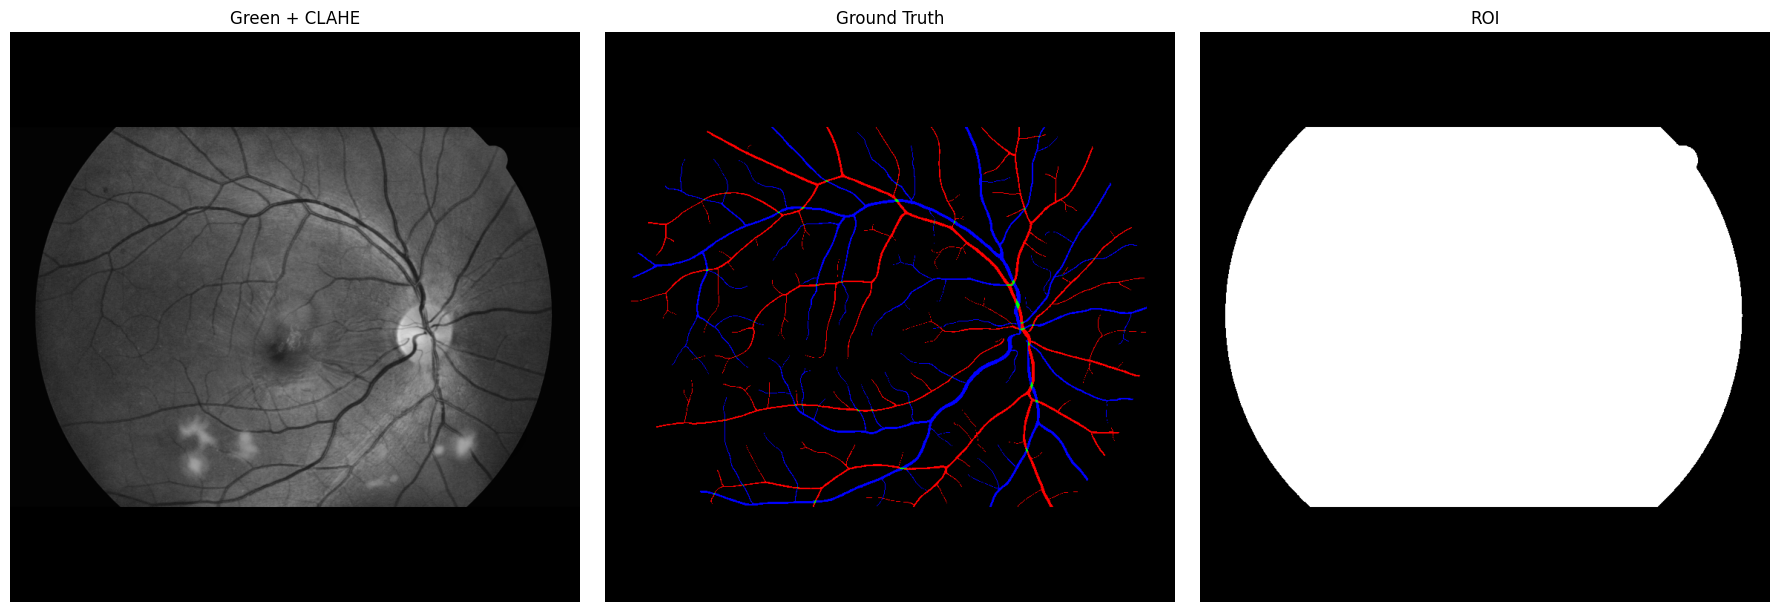

In [12]:
 
# Visual Verification
 

def class_to_rgb(mask):
    """
    Convert class mask back to RGB for visualization only.
    """

    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

    rgb[mask == 0] = [0, 0, 0]         # Background
    rgb[mask == 1] = [255, 0, 0]       # Artery
    rgb[mask == 2] = [0, 255, 0]       # Overlap
    rgb[mask == 3] = [0, 0, 255]       # Vein

    return rgb


sample = sorted(glob(os.path.join(PROCESSED_DIR, "train/images/*")))[0]

name = os.path.basename(sample)

image = cv2.imread(sample)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gt = cv2.imread(
    os.path.join(PROCESSED_DIR, "train/av", name),
    cv2.IMREAD_GRAYSCALE
)

roi = cv2.imread(
    os.path.join(PROCESSED_DIR, "train/masks", name),
    cv2.IMREAD_GRAYSCALE
)

gt_rgb = class_to_rgb(gt)

plt.figure(figsize=(18,6))

plt.subplot(131)
plt.imshow(image)
plt.title("Green + CLAHE")
plt.axis("off")

plt.subplot(132)
plt.imshow(gt_rgb)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(133)
plt.imshow(roi, cmap="gray")
plt.title("ROI")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# Patch Extraction (no filtering — weighting handles imbalance)

PATCH_DIR = os.path.join(OUTPUT_DIR, "patches")

if os.path.exists(PATCH_DIR):
    shutil.rmtree(PATCH_DIR)

for split in ["train", "val", "test"]:
    for f in ["images", "av", "masks"]:
        os.makedirs(os.path.join(PATCH_DIR, split, f), exist_ok=True)


def extract_patches(split):
    imgs = sorted(glob(os.path.join(PROCESSED_DIR, split, "images/*")))
    gts  = sorted(glob(os.path.join(PROCESSED_DIR, split, "av/*")))
    rois = sorted(glob(os.path.join(PROCESSED_DIR, split, "masks/*")))

    assert len(imgs) == len(gts) == len(rois), f"Mismatch in {split}"

    count = 0

    for ip, gp, rp in tqdm(zip(imgs, gts, rois), total=len(imgs), desc=split):

        img = cv2.imread(ip)
        gt  = cv2.imread(gp, cv2.IMREAD_GRAYSCALE)
        roi = cv2.imread(rp, cv2.IMREAD_GRAYSCALE)

        base = Path(ip).stem

        for y in range(0, IMAGE_SIZE - PATCH_SIZE + 1, PATCH_STRIDE):
            for x in range(0, IMAGE_SIZE - PATCH_SIZE + 1, PATCH_STRIDE):

                name = f"{base}_y{y}_x{x}.png"

                cv2.imwrite(
                    os.path.join(PATCH_DIR, split, "images", name),
                    img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                )
                cv2.imwrite(
                    os.path.join(PATCH_DIR, split, "av", name),
                    gt[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                )
                cv2.imwrite(
                    os.path.join(PATCH_DIR, split, "masks", name),
                    roi[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                )
                count += 1

    print(f"{split}: {count} patches")


extract_patches("train")

train: 100%|██████████| 34/34 [00:02<00:00, 14.10it/s]

train: 850 patches


In [14]:
 
# Create Augmented Dataset
 

AUGMENTED_DIR = "./Augmented_Dataset"

folders = [
    "train/images",
    "train/av",
    "train/masks",

    "val/images",
    "val/av",
    "val/masks",

    "test/images",
    "test/av",
    "test/masks"
]

if os.path.exists(AUGMENTED_DIR):
    shutil.rmtree(AUGMENTED_DIR)

for folder in folders:
    os.makedirs(os.path.join(AUGMENTED_DIR, folder), exist_ok=True)

print("Augmented dataset folders created.")

Augmented dataset folders created.


In [15]:
 
# Copy Validation and Test Sets
 

for split in ["val", "test"]:

    for folder in ["images", "av", "masks"]:

        src = os.path.join(PROCESSED_DIR, split, folder)
        dst = os.path.join(AUGMENTED_DIR, split, folder)

        for file in os.listdir(src):

            shutil.copy(
                os.path.join(src, file),
                os.path.join(dst, file)
            )

print("Validation and Test copied.")

Validation and Test copied.


In [16]:
def _rot(deg):
    return A.Rotate(limit=(deg, deg), border_mode=cv2.BORDER_CONSTANT,
                    interpolation=cv2.INTER_LINEAR,
                    mask_interpolation=cv2.INTER_NEAREST,
                    fill=0, fill_mask=0, p=1)

augmentations = {
    "hflip":        A.HorizontalFlip(p=1),
    "vflip":        A.VerticalFlip(p=1),
    "hvflip":       A.Compose([A.HorizontalFlip(p=1), A.VerticalFlip(p=1)]),
    "rot_p15":      _rot(15),
    "rot_m15":      _rot(-15),
    "rot_p25":      _rot(25),
    "rot_m25":      _rot(-25),
    "rot_p30":      _rot(30),
    "rot_m30":      _rot(-30),
    "hflip_rot20":  A.Compose([A.HorizontalFlip(p=1), _rot(20)]),
    "vflip_rot_m20":A.Compose([A.VerticalFlip(p=1), _rot(-20)]),

    "affine":       A.Affine(scale=(0.8, 1.15), translate_percent=(-0.05, 0.05),
                             shear=(-8, 8), interpolation=cv2.INTER_LINEAR,
                             mask_interpolation=cv2.INTER_NEAREST,
                             border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0, p=1),
    "elastic":      A.ElasticTransform(alpha=40, sigma=6,
                                       interpolation=cv2.INTER_LINEAR,
                                       mask_interpolation=cv2.INTER_NEAREST,
                                       border_mode=cv2.BORDER_CONSTANT,
                                       fill=0, fill_mask=0, p=1),

    "brightness":   A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1),
    "gamma":        A.RandomGamma(gamma_limit=(80, 120), p=1),
    "gaussian_blur":A.GaussianBlur(blur_limit=(3, 5), p=1),
    "gaussian_noise":A.GaussNoise(std_range=(0.02, 0.08), mean_range=(0.0, 0.0),
                                  per_channel=False, p=1),
}

# Register ROI as an additional mask target
augmentations = {
    k: A.Compose(
        v.transforms if isinstance(v, A.Compose) else [v],
        additional_targets={"roi": "mask"}
    )
    for k, v in augmentations.items()
}

In [17]:
 
# Copy Original Training Set
 
for folder in ["images", "av", "masks"]:

    src = os.path.join(PATCH_DIR, "train", folder)
    dst = os.path.join(AUGMENTED_DIR, "train", folder)

    for file in os.listdir(src):

        shutil.copy2(
            os.path.join(src, file),
            os.path.join(dst, file)
        )

print("Original training images copied.")

Original training images copied.


In [18]:
# Offline Augmentation

train_images = sorted(glob(os.path.join(PATCH_DIR, "train/images/*")))
train_gt = sorted(glob(os.path.join(PATCH_DIR, "train/av/*")))
train_roi = sorted(glob(os.path.join(PATCH_DIR, "train/masks/*")))

assert len(train_images) == len(train_gt) == len(train_roi), \
    "Mismatch between images, AV masks and ROI masks."

INTENSITY_AUGS = {
    "brightness",
    "gamma",
    "gaussian_blur",
    "gaussian_noise"
}

for img_path, gt_path, roi_path in tqdm(
    zip(train_images, train_gt, train_roi),
    total=len(train_images)
):

    # Read image (RGB)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Read masks
    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    roi = cv2.imread(roi_path, cv2.IMREAD_GRAYSCALE)

    base = Path(img_path).stem

    for aug_name, aug in augmentations.items():

        # Intensity-only augmentations
        if aug_name in INTENSITY_AUGS:

            augmented = aug(image=image)

            aug_image = augmented["image"]
            aug_gt = gt.copy()
            aug_roi = roi.copy()

        # Geometric augmentations
        else:

            augmented = aug(
                image=image,
                mask=gt,
                roi=roi
            )

            aug_image = augmented["image"]
            aug_gt = augmented["mask"]
            aug_roi = augmented["roi"]

        filename = f"{base}_{aug_name}.png"

        cv2.imwrite(
            os.path.join(AUGMENTED_DIR, "train/images", filename),
            cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)
        )

        cv2.imwrite(
            os.path.join(AUGMENTED_DIR, "train/av", filename),
            aug_gt
        )

        cv2.imwrite(
            os.path.join(AUGMENTED_DIR, "train/masks", filename),
            aug_roi
        )

print("Offline augmentation completed.")

100%|██████████| 850/850 [00:42<00:00, 20.01it/s]

Offline augmentation completed.


In [19]:
# Dataset Statistics

for split in ["train", "val", "test"]:

    n_images = len(glob(os.path.join(AUGMENTED_DIR, split, "images", "*")))
    n_gt = len(glob(os.path.join(AUGMENTED_DIR, split, "av", "*")))
    n_roi = len(glob(os.path.join(AUGMENTED_DIR, split, "masks", "*")))

    assert n_images == n_gt == n_roi, \
        f"{split}: Dataset mismatch ({n_images}, {n_gt}, {n_roi})"

    print(f"{split:5s} : {n_images:4d} samples")

print("\nDataset verification completed successfully.")

train : 15300 samples
val   :    8 samples
test  :    8 samples

Dataset verification completed successfully.


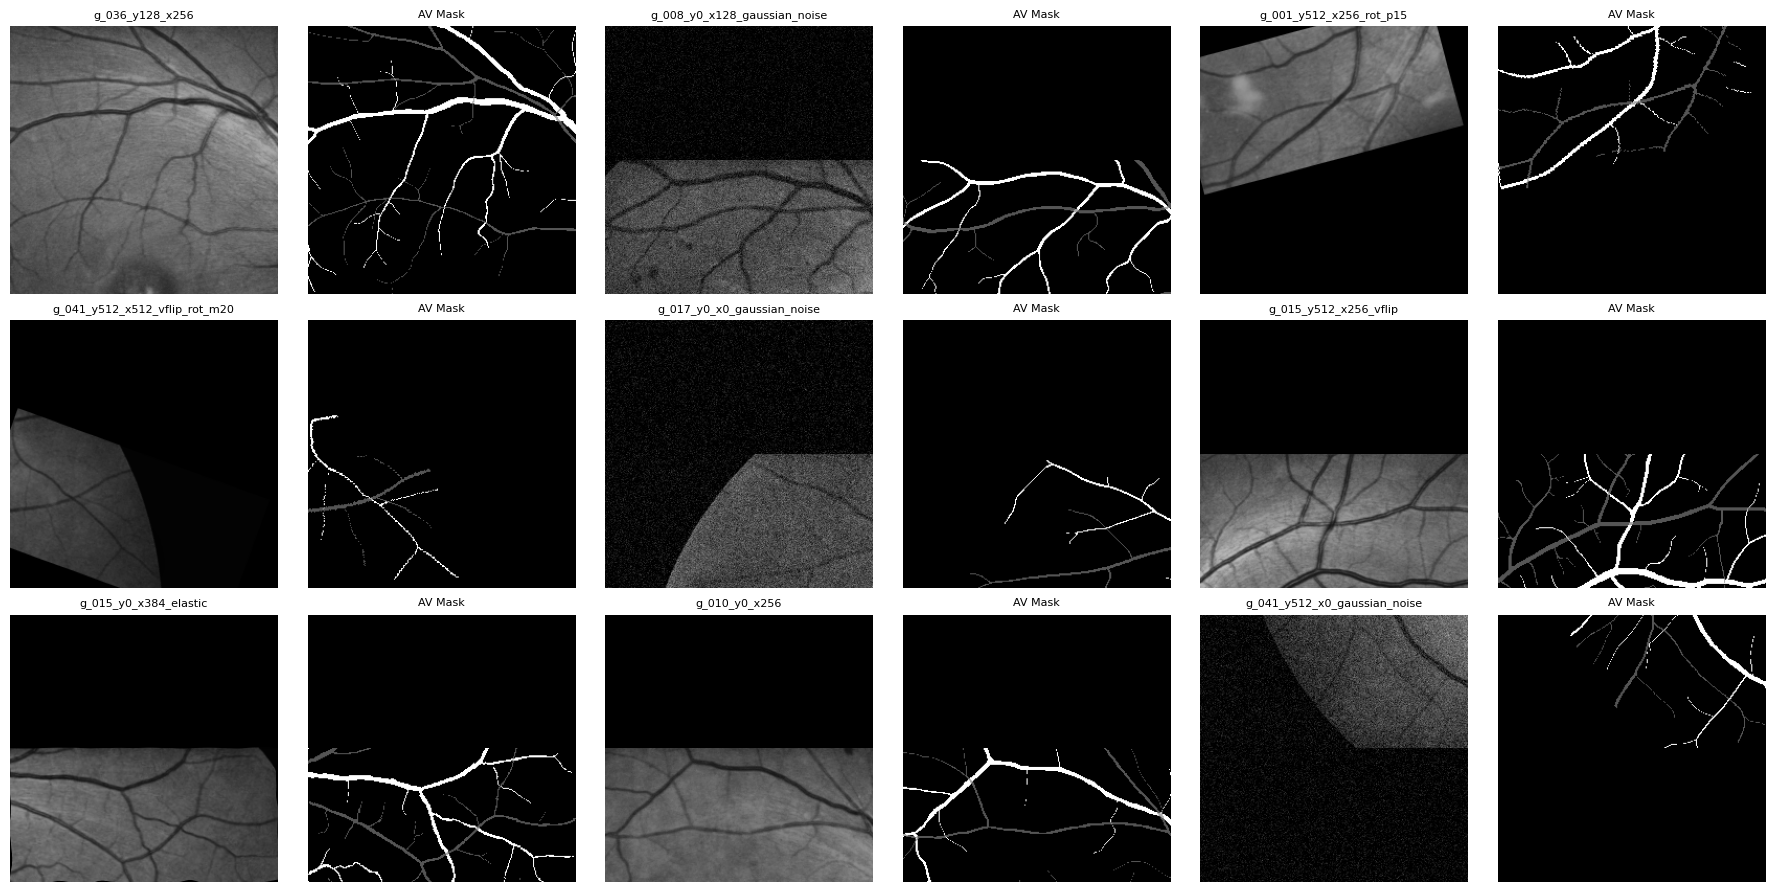

In [20]:
# Visualize Augmentations

import random

samples = random.sample(
    sorted(glob(os.path.join(AUGMENTED_DIR, "train/images/*"))),
    9
)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))

for i, img_path in enumerate(samples):

    base = Path(img_path).name

    gt_path = os.path.join(AUGMENTED_DIR, "train/av", base)

    # RGB image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # AV mask
    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)

    axes[i // 3, (i % 3) * 2].imshow(image)
    axes[i // 3, (i % 3) * 2].set_title(Path(img_path).stem, fontsize=8)
    axes[i // 3, (i % 3) * 2].axis("off")

    axes[i // 3, (i % 3) * 2 + 1].imshow(gt, cmap="gray")
    axes[i // 3, (i % 3) * 2 + 1].set_title("AV Mask", fontsize=8)
    axes[i // 3, (i % 3) * 2 + 1].axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Dataset Class

class RetinalDataset(Dataset):

    def __init__(self, image_dir, mask_dir, compute_weights=False):

        self.images = sorted(glob(os.path.join(image_dir, "*")))
        self.masks  = sorted(glob(os.path.join(mask_dir, "*")))

        assert len(self.images) == len(self.masks), \
            "Mismatch between images and masks."

        self.weights = None

        if compute_weights:

            w = []

            for m in tqdm(self.masks, desc="Computing sample weights"):

                gt = cv2.imread(m, cv2.IMREAD_GRAYSCALE)

                vessel  = (gt > 0).mean()
                overlap = (gt == 2).mean()

                w.append(
                    max(vessel, WEIGHT_FLOOR) ** 0.5
                    + OVERLAP_BOOST * (overlap ** 0.5)
                )

            self.weights = np.array(w, dtype=np.float64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx], cv2.IMREAD_GRAYSCALE)

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        image = torch.from_numpy(image).float()
        mask  = torch.from_numpy(mask).long()

        return image, mask

In [22]:
 
# DataLoaders
 

from torch.utils.data import WeightedRandomSampler

train_dataset = RetinalDataset(
    os.path.join(AUGMENTED_DIR, "train/images"),
    os.path.join(AUGMENTED_DIR, "train/av"),
    compute_weights=True
)

val_dataset = RetinalDataset(

    os.path.join(AUGMENTED_DIR, "val/images"),
    os.path.join(AUGMENTED_DIR, "val/av")

)

test_dataset = RetinalDataset(

    os.path.join(AUGMENTED_DIR, "test/images"),
    os.path.join(AUGMENTED_DIR, "test/av")

)

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(train_dataset.weights),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))

Computing sample weights: 100%|██████████| 15300/15300 [00:54<00:00, 278.20it/s]

Train : 15300
Validation : 8
Test : 8


In [23]:
w = train_dataset.weights

print("Weight percentiles [0,25,50,75,100]:")
print(np.percentile(w, [0, 25, 50, 75, 100]))
print(f"Max/Min ratio : {w.max() / w.min():.1f}x")
print(f"Effective unique samples : {(w.sum()**2)/(w**2).sum():.0f} / {len(w)}")

Weight percentiles [0,25,50,75,100]:
[0.08916181 0.22230889 0.28130748 0.35464118 0.56828816]
Max/Min ratio : 6.4x
Effective unique samples : 13883 / 15300


In [24]:
# Verify Dataset

images, masks = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Masks Shape  :", masks.shape)

print("Image dtype  :", images.dtype)
print("Mask dtype   :", masks.dtype)

print("Image Range  :", images.min().item(), "to", images.max().item())

print("Unique Classes :", torch.unique(masks))

Images Shape : torch.Size([8, 3, 256, 256])
Masks Shape  : torch.Size([8, 256, 256])
Image dtype  : torch.float32
Mask dtype   : torch.int64
Image Range  : 0.0 to 0.9215686321258545
Unique Classes : tensor([0, 1, 2, 3])


In [25]:
# Double Convolution Block
 
import math
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        groups = math.gcd(8, out_channels)

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.conv(x)

In [26]:
# Attention Gate

import math

class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):

        super().__init__()


        groups = math.gcd(8, F_int)

        self.W_g = nn.Sequential(

            nn.Conv2d(
                F_g,
                F_int,
                kernel_size=1,
                bias=True
            ),

            nn.GroupNorm(
                groups,
                F_int
            )

        )

        self.W_x = nn.Sequential(

            nn.Conv2d(
                F_l,
                F_int,
                kernel_size=1,
                bias=True
            ),

            nn.GroupNorm(
                groups,
                F_int
            )

        )

        self.psi = nn.Sequential(

            nn.Conv2d(
                F_int,
                1,
                kernel_size=1,
                bias=True
            ),

            nn.Sigmoid()

        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)

        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        return x * psi

In [27]:
# Encoder Block

class EncoderBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = DoubleConv(in_channels, out_channels)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        skip = self.conv(x)

        pooled = self.pool(skip)

        return skip, pooled

In [28]:
# Decoder Block

class DecoderBlock(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.attention = AttentionBlock(
            F_g=out_channels,
            F_l=skip_channels,
            F_int=out_channels // 2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        skip = self.attention(x, skip)

        x = torch.cat([skip, x], dim=1)

        return self.conv(x)

In [29]:
# Attention U-Net with Deep Supervision

class AttentionUNet(nn.Module):

    def __init__(self, in_channels=3, num_classes=4):

        super().__init__()

        # Encoder

        self.enc1 = EncoderBlock(in_channels, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)

        # Bottleneck

        self.bottleneck = DoubleConv(512, 1024)

        # Decoder

        self.dec4 = DecoderBlock(1024, 512, 512)
        self.dec3 = DecoderBlock(512, 256, 256)
        self.dec2 = DecoderBlock(256, 128, 128)
        self.dec1 = DecoderBlock(128, 64, 64)
        


        # Main Output

        self.out = nn.Conv2d(
            64,
            num_classes,
            kernel_size=1
        )

        # Deep Supervision Heads

        self.ds4 = nn.Conv2d(
            512,
            num_classes,
            kernel_size=1
        )

        self.ds3 = nn.Conv2d(
            256,
            num_classes,
            kernel_size=1
        )

        self.ds2 = nn.Conv2d(
            128,
            num_classes,
            kernel_size=1
        )
        
        self.initialize_weights()
        
    def initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m, nn.GroupNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):

        # Encoder

        s1, p1 = self.enc1(x)

        s2, p2 = self.enc2(p1)

        s3, p3 = self.enc3(p2)

        s4, p4 = self.enc4(p3)

        # Bottleneck

        b = self.bottleneck(p4)

        # Decoder

        d4 = self.dec4(b, s4)

        d3 = self.dec3(d4, s3)

        d2 = self.dec2(d3, s2)

        d1 = self.dec1(d2, s1)

        # Main Prediction

        out = self.out(d1)

        # Deep Supervision

        aux4 = self.ds4(d4)

        aux3 = self.ds3(d3)

        aux2 = self.ds2(d2)

        

        return (

    out,

    F.interpolate(
        aux2,
        size=out.shape[2:],
        mode="bilinear",
        align_corners=False
    ),
    

    F.interpolate(
        aux3,
        size=out.shape[2:],
        mode="bilinear",
        align_corners=False
    ),

    F.interpolate(
        aux4,
        size=out.shape[2:],
        mode="bilinear",
        align_corners=False
    )
    
    

)

In [30]:
model = AttentionUNet(
    in_channels=3,
    num_classes=NUM_CLASSES
).to(DEVICE)

print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model Parameters: 31,392,948
Trainable Parameters: 31,392,948


In [31]:
# Multi-Class Focal Tversky Loss

class FocalTverskyLoss(nn.Module):

    def __init__(
        self,
        alpha=0.3,
        beta=0.7,
        gamma=4/3,
        smooth=1e-6,
        num_classes=NUM_CLASSES
    ):
        super().__init__()

        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth
        self.num_classes = num_classes

    def forward(self, logits, targets):

        # Convert logits to probabilities
        probs = torch.softmax(logits, dim=1)

        # Convert targets to one-hot encoding
        targets_onehot = F.one_hot(
            targets,
            self.num_classes
        ).permute(0, 3, 1, 2).float()

        # Flatten spatial dimensions
        probs = probs.flatten(2)
        targets_onehot = targets_onehot.flatten(2)

        # Compute Tversky statistics
        TP = (probs * targets_onehot).sum(dim=2)
        FP = (probs * (1 - targets_onehot)).sum(dim=2)
        FN = ((1 - probs) * targets_onehot).sum(dim=2)

        tversky = (
            TP + self.smooth
        ) / (
            TP +
            self.alpha * FP +
            self.beta * FN +
            self.smooth
        )

        focal_tversky = (1.0 - tversky) ** self.gamma

        return focal_tversky.mean()

In [32]:
 # Soft Skeletonization
 
def soft_erode(img):

    if img.dim() == 4:

        p1 = -F.max_pool2d(-img, (3,1), stride=1, padding=(1,0))

        p2 = -F.max_pool2d(-img, (1,3), stride=1, padding=(0,1))

        return torch.min(p1, p2)

    raise ValueError("Expected 4D tensor")


def soft_dilate(img):

    return F.max_pool2d(
        img,
        kernel_size=3,
        stride=1,
        padding=1
    )


def soft_open(img):

    return soft_dilate(
        soft_erode(img)
    )


def soft_skeletonize(img, iterations=10):

    img1 = soft_open(img)

    skeleton = F.relu(img - img1)

    for _ in range(iterations):

        img = soft_erode(img)

        opened = soft_open(img)

        delta = F.relu(img-opened)

        skeleton = skeleton + F.relu(delta - skeleton*delta)

    return skeleton

In [33]:
# Multi-Class CLDice Loss

class CLDiceLoss(nn.Module):

    def __init__(
        self,
        num_classes=NUM_CLASSES,
        iterations=10,
        smooth=1e-6
    ):

        super().__init__()

        self.num_classes = num_classes
        self.iterations = iterations
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.softmax(logits, dim=1)
        
        # Ignore background channel
        probs = probs[:, 1:, :, :]

        targets = F.one_hot(
            targets,
            self.num_classes
        ).permute(0,3,1,2).float()

        targets = targets[:, 1:, :, :]
        
        skel_pred = soft_skeletonize(
            probs,
            self.iterations
        )

        skel_gt = soft_skeletonize(
            targets,
            self.iterations
        )

        tprec = (

            (skel_pred * targets).sum((2,3))

            + self.smooth

        ) / (

            skel_pred.sum((2,3))

            + self.smooth

        )

        tsens = (

            (skel_gt * probs).sum((2,3))

            + self.smooth

        ) / (

            skel_gt.sum((2,3))

            + self.smooth

        )

        cldice = (

            2*tprec*tsens

        ) / (

            tprec + tsens + self.smooth

        )

        return 1 - cldice.mean()

In [34]:
focal_tversky_loss = FocalTverskyLoss(
    alpha=0.25,
    beta=0.75,
    gamma=4/3,
    num_classes=NUM_CLASSES
)

cldice_loss = CLDiceLoss(
    num_classes=NUM_CLASSES,
    iterations=6
)

In [35]:
# Hybrid Loss with clDice warmup
CLDICE_START_EPOCH = 20
FT_WEIGHT = 0.75
CL_WEIGHT = 0.25

def hybrid_loss(outputs, targets, epoch=0):
    main, aux2, aux3, aux4 = outputs

    ft_main = focal_tversky_loss(main, targets)

    if epoch >= CLDICE_START_EPOCH:
        with torch.amp.autocast("cuda", enabled=False):
            cl_main = cldice_loss(main.float(), targets)
        main_loss = FT_WEIGHT * ft_main + CL_WEIGHT * cl_main
    else:
        main_loss = ft_main

    aux2_loss = focal_tversky_loss(aux2, targets)
    aux3_loss = focal_tversky_loss(aux3, targets)
    aux4_loss = focal_tversky_loss(aux4, targets)

    return main_loss + 0.40*aux2_loss + 0.25*aux3_loss + 0.15*aux4_loss

In [36]:
# Optimizer

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY

)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=20,
    T_mult=1,
    eta_min=1e-6

)

scaler = torch.cuda.amp.GradScaler()
print("Optimizer, Scheduler and AMP initialized.")

Optimizer, Scheduler and AMP initialized.


In [37]:
@torch.no_grad()
def dice_score(
    preds,
    targets,
    num_classes=NUM_CLASSES,
    ignore_background=True,
    smooth=1e-6
):

    preds = torch.argmax(preds, dim=1)

    dice_scores = []

    start_class = 1 if ignore_background else 0

    for cls in range(start_class, num_classes):

        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        dice = (2.0 * intersection + smooth) / (union + smooth)

        dice_scores.append(dice)

    dice_scores = torch.stack(dice_scores)

    mean_dice = dice_scores.mean().item()

    return mean_dice, dice_scores.cpu().tolist()

In [38]:
@torch.no_grad()
def iou_score(
    preds,
    targets,
    num_classes=NUM_CLASSES,
    ignore_background=True,
    smooth=1e-6
):

    preds = torch.argmax(preds, dim=1)

    iou_scores = []

    start_class = 1 if ignore_background else 0

    for cls in range(start_class, num_classes):

        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum() - intersection

        iou = (intersection + smooth) / (union + smooth)

        iou_scores.append(iou)

    iou_scores = torch.stack(iou_scores)

    mean_iou = iou_scores.mean().item()

    return mean_iou, iou_scores.cpu().tolist()

In [39]:
# Precision, Recall, F1, Accuracy and Confusion Matrix

from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    accuracy_score
)

CLASS_NAMES = [
    "Background",
    "Artery",
    "Overlap",
    "Vein"
]

VESSEL_CLASSES = [
    "Artery",
    "Overlap",
    "Vein"
]


@torch.no_grad()
def classification_metrics(preds, targets):

    preds = preds.detach()
    preds = torch.argmax(preds, dim=1)
    preds = preds.cpu().numpy().ravel()

    targets = targets.detach().cpu().numpy().ravel()

    precision, recall, f1, support = precision_recall_fscore_support(
        targets,
        preds,
        labels=[0, 1, 2, 3],
        average=None,
        zero_division=0
    )

    accuracy = accuracy_score(
        targets,
        preds
    )

    cm = confusion_matrix(
        targets,
        preds,
        labels=[0, 1, 2, 3]
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
        "confusion_matrix": cm
    }

In [40]:
# Train One Epoch

def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    device,
    epoch=0
):

    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    running_acc = 0.0
    running_precision = np.zeros(NUM_CLASSES)
    running_recall = np.zeros(NUM_CLASSES)
    running_f1 = np.zeros(NUM_CLASSES)

    progress = tqdm(loader)

    for images, masks in progress:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = hybrid_loss(
                outputs,
                masks,
                epoch
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        # Main prediction only
        main_output = outputs[0]

        dice, _ = dice_score(
            main_output,
            masks
        )

        iou, _ = iou_score(
            main_output,
            masks
        )

        metrics = classification_metrics(
            main_output,
            masks
        )

        running_loss += float(loss.detach())
        running_dice += dice
        running_iou += iou

        running_acc += metrics["accuracy"]
        running_precision += metrics["precision"]
        running_recall += metrics["recall"]
        running_f1 += metrics["f1"]

        progress.set_postfix(
            Loss=f"{float(loss.detach()):.4f}",
            Dice=f"{dice:.4f}",
            IoU=f"{iou:.4f}"
        )

    n = len(loader)

    return (
        running_loss / n,
        running_dice / n,
        running_iou / n,
        running_acc / n,
        running_precision / n,
        running_recall / n,
        running_f1 / n
    )

In [41]:
# Validate One Epoch

def validate_one_epoch(
    model,
    loader,
    device,
    epoch=0
):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    running_acc = 0.0
    running_precision = np.zeros(NUM_CLASSES)
    running_recall = np.zeros(NUM_CLASSES)
    running_f1 = np.zeros(NUM_CLASSES)

    with torch.no_grad():

        progress = tqdm(loader)

        for images, masks in progress:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = hybrid_loss(
                    outputs,
                    masks,
                    epoch
                )

            # Main prediction only
            main_output = outputs[0]

            dice, _ = dice_score(
                main_output,
                masks
            )

            iou, _ = iou_score(
                main_output,
                masks
            )

            metrics = classification_metrics(
                main_output,
                masks
            )

            running_loss += float(loss.detach())
            running_dice += dice
            running_iou += iou

            running_acc += metrics["accuracy"]
            running_precision += metrics["precision"]
            running_recall += metrics["recall"]
            running_f1 += metrics["f1"]

            progress.set_postfix(
                Loss=f"{float(loss.detach()):.4f}",
                Dice=f"{dice:.4f}",
                IoU=f"{iou:.4f}"
            )

    n = len(loader)

    return (
        running_loss / n,
        running_dice / n,
        running_iou / n,
        running_acc / n,
        running_precision / n,
        running_recall / n,
        running_f1 / n
    )

In [42]:
model.eval()

with torch.no_grad():

    images, masks = next(iter(train_loader))
    images = images.to(DEVICE, non_blocking=True)

    outputs = model(images)

    print(f"Output type : {type(outputs)}")
    print(f"Number of outputs : {len(outputs)}\n")

    for i, out in enumerate(outputs):
        print(f"Output {i}: {tuple(out.shape)}")

del outputs, images, masks
torch.cuda.empty_cache()

Output type : <class 'tuple'>
Number of outputs : 4

Output 0: (8, 4, 256, 256)
Output 1: (8, 4, 256, 256)
Output 2: (8, 4, 256, 256)
Output 3: (8, 4, 256, 256)


In [43]:
# Early Stopping Helper

def early_stopping(
    current_score,
    best_score,
    counter,
    patience
):
    """
    Early stopping based on validation Dice.

    Returns:
        best_score (float)
        counter (int)
        should_stop (bool)
        is_best (bool)
    """

    if current_score > best_score:

        best_score = current_score
        counter = 0

        return best_score, counter, False, True

    counter += 1

    if counter >= patience:
        return best_score, counter, True, False

    return best_score, counter, False, False

In [44]:
# Complete Training Loop

best_dice = 0.0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

for epoch in range(EPOCHS):

    print("=" * 40)
    print(f"Epoch [{epoch + 1}/{EPOCHS}]")
    print("=" * 40)

    train_results = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scaler,
        DEVICE,
        epoch
    )

    val_results = validate_one_epoch(
        model,
        val_loader,
        DEVICE,epoch
    )

    scheduler.step()

    (
        train_loss,
        train_dice,
        train_iou,
        train_acc,
        train_prec,
        train_rec,
        train_f1
    ) = train_results

    (
        val_loss,
        val_dice,
        val_iou,
        val_acc,
        val_prec,
        val_rec,
        val_f1
    ) = val_results

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print()
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Dice : {train_dice:.4f}")
    print(f"Train IoU  : {train_iou:.4f}")

    print()
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")
    print(f"Val IoU    : {val_iou:.4f}")

    print()
    print(f"Validation Accuracy : {val_acc:.4f}")

    print("\nPer Class Metrics")

    for i, cls in enumerate(CLASS_NAMES):
        print(
            f"{cls:12s} | "
            f"P={val_prec[i]:.3f} "
            f"R={val_rec[i]:.3f} "
            f"F1={val_f1[i]:.3f}"
        )

    # Early Stopping

    best_dice, epochs_without_improvement, stop, is_best = early_stopping(
        val_dice,
        best_dice,
        epochs_without_improvement,
        EARLY_STOPPING_PATIENCE
    )

    if is_best:

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_dice": best_dice,
                "history": history,
            },
            "attention_unet_aug_heavy.pth"
        )

        print("\nBest model saved.")

    else:

        print(
            f"\nEarly Stopping Counter: "
            f"{epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
        )

    if stop:

        print("\nEarly stopping triggered.")
        break

print("\nTraining Complete.")

Epoch [1/200]


100%|██████████| 8/8 [00:01<00:00,  7.18it/s, Dice=0.4832, IoU=0.3513, Loss=0.5635]



Train Loss : 0.7188
Train Dice : 0.4060
Train IoU  : 0.2779

Val Loss   : 0.5833
Val Dice   : 0.4685
Val IoU    : 0.3310

Validation Accuracy : 0.9682

Per Class Metrics
Background   | P=0.993 R=0.979 F1=0.986
Artery       | P=0.461 R=0.710 F1=0.556
Overlap      | P=0.223 R=0.145 F1=0.172
Vein         | P=0.628 R=0.739 F1=0.677

Best model saved.
Epoch [2/200]


100%|██████████| 8/8 [00:00<00:00,  8.02it/s, Dice=0.5100, IoU=0.3702, Loss=0.4984]



Train Loss : 0.5546
Train Dice : 0.5059
Train IoU  : 0.3622

Val Loss   : 0.5327
Val Dice   : 0.4891
Val IoU    : 0.3474

Validation Accuracy : 0.9677

Per Class Metrics
Background   | P=0.994 R=0.977 F1=0.986
Artery       | P=0.490 R=0.719 F1=0.578
Overlap      | P=0.147 R=0.372 F1=0.206
Vein         | P=0.602 R=0.794 F1=0.683

Best model saved.
Epoch [3/200]


...


Train Loss : 0.3819
Train Dice : 0.6689
Train IoU  : 0.5119

Val Loss   : 0.5034
Val Dice   : 0.5602
Val IoU    : 0.4116

Validation Accuracy : 0.9718

Per Class Metrics
Background   | P=0.994 R=0.978 F1=0.986
Artery       | P=0.546 R=0.820 F1=0.653
Overlap      | P=0.494 R=0.219 F1=0.302
Vein         | P=0.645 R=0.834 F1=0.725

Early Stopping Counter: 23/25
Epoch [38/200]


100%|██████████| 8/8 [00:01<00:00,  7.45it/s, Dice=0.5942, IoU=0.4419, Loss=0.4480]



Train Loss : 0.3798
Train Dice : 0.6712
Train IoU  : 0.5141

Val Loss   : 0.5022
Val Dice   : 0.5632
Val IoU    : 0.4148

Validation Accuracy : 0.9723

Per Class Metrics
Background   | P=0.994 R=0.979 F1=0.987
Artery       | P=0.554 R=0.815 F1=0.657
Overlap      | P=0.494 R=0.220 F1=0.303
Vein         | P=0.653 R=0.831 F1=0.729

Early Stopping Counter: 24/25
Epoch [39/200]


100%|██████████| 8/8 [00:01<00:00,  7.55it/s, Dice=0.5922, IoU=0.4397, Loss=0.4490]


Train Loss : 0.3784
Train Dice : 0.6728
Train IoU  : 0.5158

Val Loss   : 0.5027
Val Dice   : 0.5605
Val IoU    : 0.4122

Validation Accuracy : 0.9719

Per Class Metrics
Background   | P=0.994 R=0.979 F1=0.986
Artery       | P=0.546 R=0.820 F1=0.653
Overlap      | P=0.488 R=0.219 F1=0.301
Vein         | P=0.649 R=0.833 F1=0.727

Early Stopping Counter: 25/25

Early stopping triggered.

Training Complete.


In [49]:
# Test Model

def test_model(model, loader, device, epoch=EPOCHS):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    all_preds = []
    all_targets = []

    with torch.no_grad():

        for images, masks in tqdm(loader, desc="Testing"):

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = hybrid_loss(
                    outputs,
                    masks,
                    epoch
                )

            # Main Output

            main_output = outputs[0]

            dice, _ = dice_score(
                main_output,
                masks
            )

            iou, _ = iou_score(
                main_output,
                masks
            )

            running_loss += float(loss.detach())
            running_dice += dice
            running_iou += iou

            preds = torch.argmax(
                main_output,
                dim=1
            )

            all_preds.extend(
                preds.cpu().numpy().ravel()
            )

            all_targets.extend(
                masks.cpu().numpy().ravel()
            )

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets,
        all_preds,
        labels=list(range(NUM_CLASSES)),
        average=None,
        zero_division=0
    )

    accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    print("=" * 80)
    print("TEST SET RESULTS")
    print("=" * 80)

    print(f"Test Loss : {running_loss / len(loader):.4f}")
    print(f"Test Dice : {running_dice / len(loader):.4f}")
    print(f"Test IoU  : {running_iou / len(loader):.4f}")
    print(f"Test Acc  : {accuracy:.4f}")

    print("\nPer Class Metrics")

    for i, cls in enumerate(CLASS_NAMES):

        print(
            f"{cls:12s} | "
            f"P={precision[i]:.3f} "
            f"R={recall[i]:.3f} "
            f"F1={f1[i]:.3f}"
        )

    return {
        "loss": running_loss / len(loader),
        "dice": running_dice / len(loader),
        "iou": running_iou / len(loader),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [50]:
# Run Test Evaluation

checkpoint = torch.load(
    "attention_unet_aug_heavy.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

test_results = test_model(
    model,
    test_loader,
    DEVICE
)

Testing: 100%|██████████| 8/8 [00:01<00:00,  7.13it/s]


TEST SET RESULTS
Test Loss : 0.5239
Test Dice : 0.5584
Test IoU  : 0.4107
Test Acc  : 0.9730

Per Class Metrics
Background   | P=0.994 R=0.981 F1=0.987
Artery       | P=0.553 R=0.774 F1=0.645
Overlap      | P=0.383 R=0.247 F1=0.300
Vein         | P=0.673 R=0.809 F1=0.735


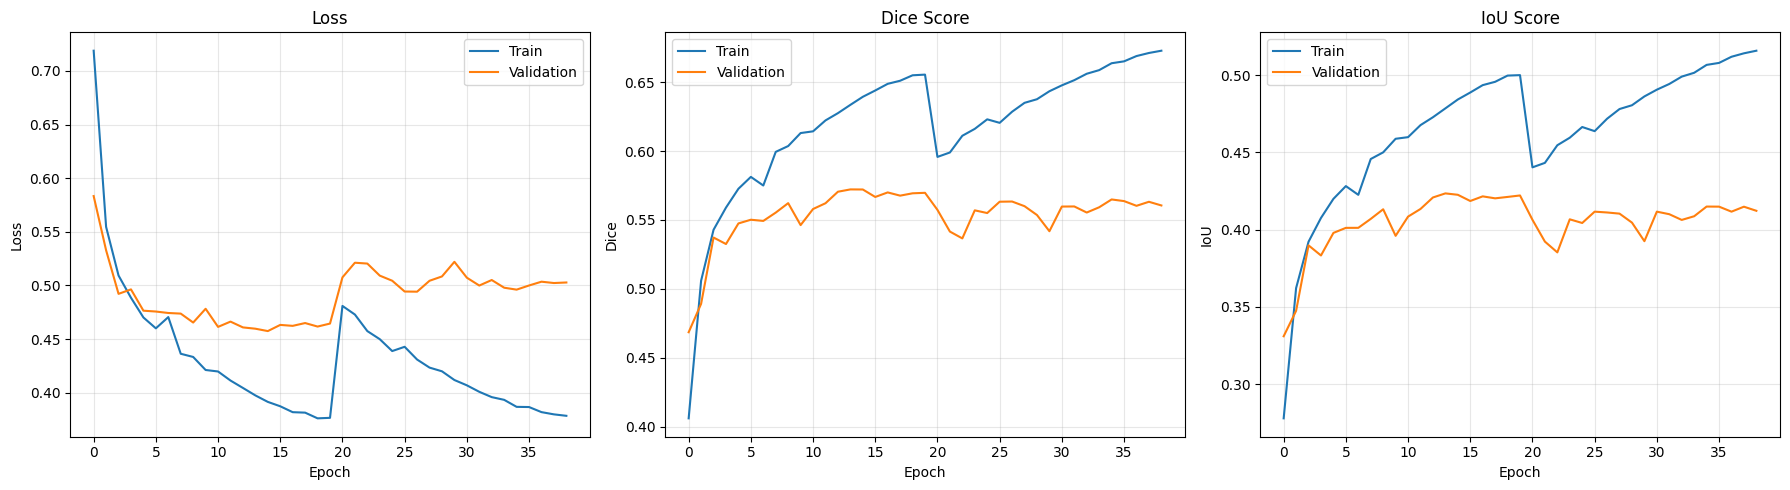

In [ ]:
# Training Curves

plt.figure(figsize=(18, 5))

# ---------------- Loss ---------------- #

plt.subplot(1, 3, 1)

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

# ---------------- Dice ---------------- #

plt.subplot(1, 3, 2)

plt.plot(history["train_dice"], label="Train")
plt.plot(history["val_dice"], label="Validation")

plt.title("Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.grid(True, alpha=0.3)
plt.legend()

# ---------------- IoU ---------------- #

plt.subplot(1, 3, 3)

plt.plot(history["train_iou"], label="Train")
plt.plot(history["val_iou"], label="Validation")

plt.title("IoU Score")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.grid(True, alpha=0.3)
plt.legend()  

plt.tight_layout()
plt.show()

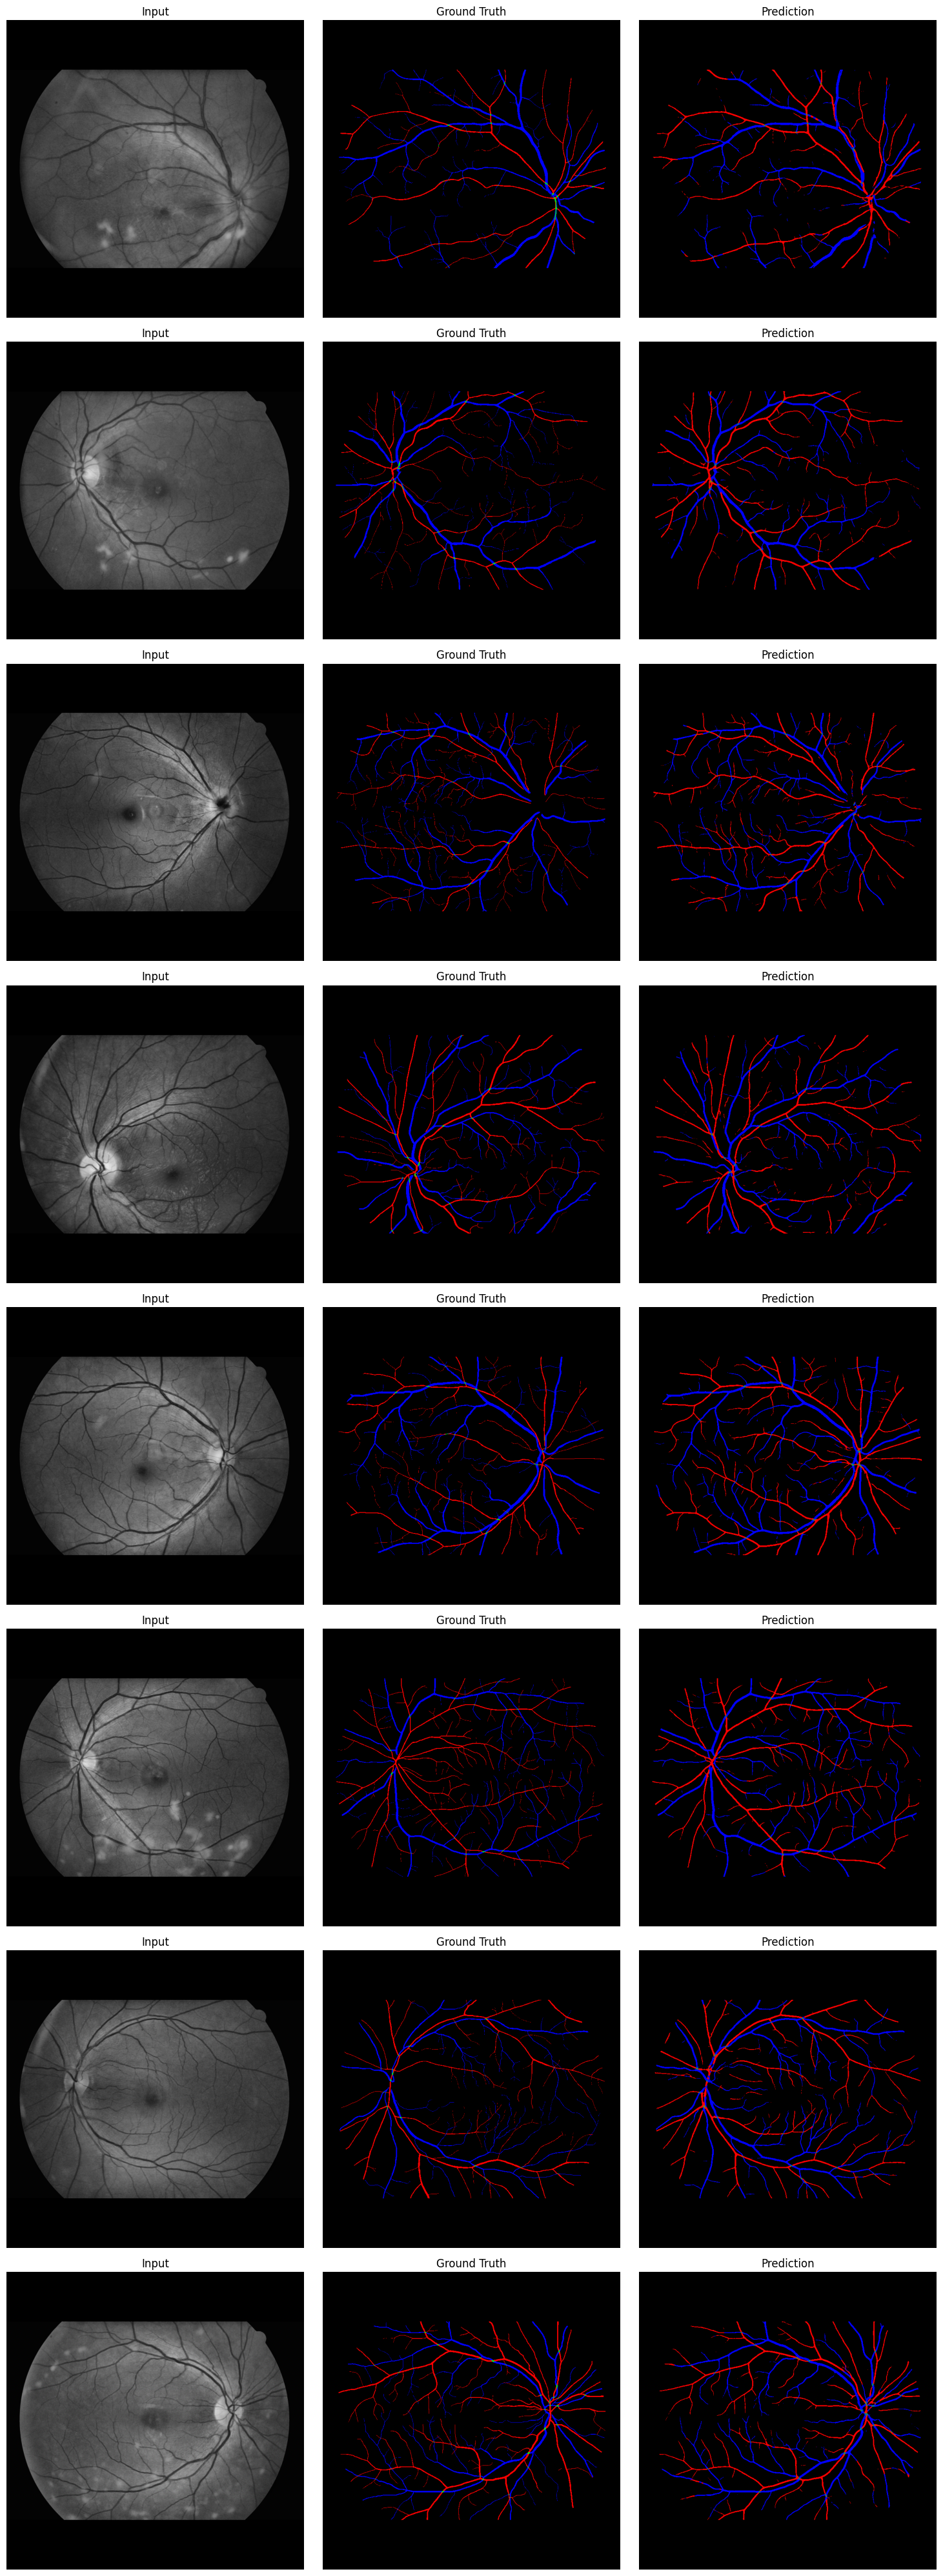

In [52]:
# Visualization

model.eval()

num_examples = 8

indices = np.random.choice(
    len(test_dataset),
    num_examples,
    replace=False
)

plt.figure(figsize=(15, 5 * num_examples))

with torch.no_grad():

    for row, idx in enumerate(indices):

        image, gt = test_dataset[idx]

        image_gpu = image.unsqueeze(0).to(
            DEVICE,
            non_blocking=True
        )

        with torch.amp.autocast("cuda"):

            outputs = model(image_gpu)

        main_output = outputs[0]

        pred = torch.argmax(
            main_output,
            dim=1
        ).squeeze().cpu().numpy()

        gt = gt.numpy()

        pred_rgb = class_to_rgb(pred)
        gt_rgb = class_to_rgb(gt)

        image_rgb = image.permute(1, 2, 0).numpy()

        plt.subplot(num_examples, 3, row * 3 + 1)
        plt.imshow(image_rgb)
        plt.title("Input")
        plt.axis("off")

        plt.subplot(num_examples, 3, row * 3 + 2)
        plt.imshow(gt_rgb)
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_examples, 3, row * 3 + 3)
        plt.imshow(pred_rgb)
        plt.title("Prediction")
        plt.axis("off")

plt.tight_layout()
plt.show()